# Borrower Risk Intelligence System
## Notebook 1 — Exploratory Data Analysis

**Objective:** Understand the structure, quality, and patterns in the Home Credit Default Risk dataset before any modelling begins.

---

**Contents**
1. Dataset loading
2. Target variable — class imbalance
3. Missing value assessment
4. Key numerical feature distributions
5. Age and employment analysis
6. Income vs loan amount
7. Correlation analysis
8. Categorical feature analysis
9. Findings summary

## 0 — Dataset Download (Google Colab)
Upload your `kaggle.json` API token when prompted.

In [19]:
from google.colab import files
import os

files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.system('mv kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle competitions download -c home-credit-default-risk')
os.system('unzip -q home-credit-default-risk.zip')

Saving kaggle.json to kaggle.json


256

## 1 — Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

## 2 — Load Dataset

In [21]:
df = pd.read_csv('application_train.csv')

print(f'Rows: {df.shape[0]:,}')
print(f'Features: {df.shape[1]}')

Rows: 307,511
Features: 122


In [22]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [24]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.000000,278180.518577,102790.175348,100002.000000,189145.500000,278202.000000,367142.500000,456255.000000
TARGET,307511.000000,0.080729,0.272419,0.000000,0.000000,0.000000,0.000000,1.000000
CNT_CHILDREN,307511.000000,0.417052,0.722121,0.000000,0.000000,0.000000,1.000000,19.000000
AMT_INCOME_TOTAL,307511.000000,168797.919297,237123.146279,25650.000000,112500.000000,147150.000000,202500.000000,117000000.000000
AMT_CREDIT,307511.000000,599025.999706,402490.776996,45000.000000,270000.000000,513531.000000,808650.000000,4050000.000000
AMT_ANNUITY,307499.000000,27108.573909,14493.737315,1615.500000,16524.000000,24903.000000,34596.000000,258025.500000
AMT_GOODS_PRICE,307233.000000,538396.207429,369446.460540,40500.000000,238500.000000,450000.000000,679500.000000,4050000.000000
REGION_POPULATION_RELATIVE,307511.000000,0.020868,0.013831,0.000290,0.010006,0.018850,0.028663,0.072508
DAYS_BIRTH,307511.000000,-16036.995067,4363.988632,-25229.000000,-19682.000000,-15750.000000,-12413.000000,-7489.000000
DAYS_EMPLOYED,307511.000000,63815.045904,141275.766519,-17912.000000,-2760.000000,-1213.000000,-289.000000,365243.000000


## 3 — Target Variable

- `TARGET = 1` — borrower defaulted
- `TARGET = 0` — borrower repaid

If the dataset is heavily imbalanced, a naive model can hit high accuracy by predicting 0 every time — catching zero actual defaulters. Checking this before anything else.

In [25]:
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print(f'Non-Default (0): {target_counts[0]:,}  ({target_pct[0]:.1f}%)')
print(f'Default     (1): {target_counts[1]:,}  ({target_pct[1]:.1f}%)')
print(f'Imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1')

Non-Default (0): 282,686  (91.9%)
Default     (1): 24,825  (8.1%)
Imbalance ratio: 11.4:1


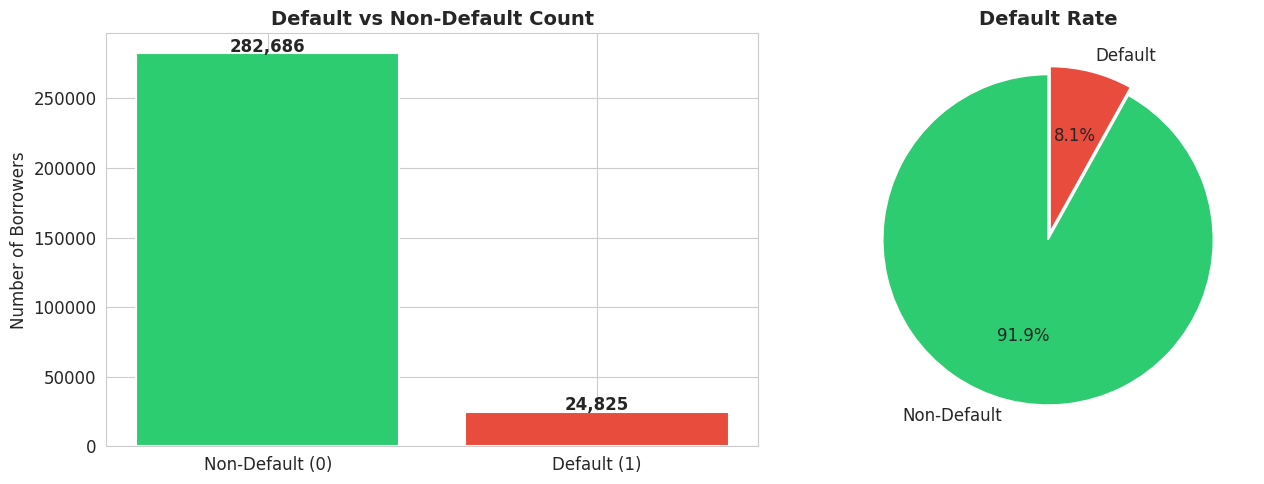

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Non-Default (0)', 'Default (1)'],
            target_counts.values,
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Default vs Non-Default Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Borrowers')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts.values,
            labels=['Non-Default', 'Default'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Default Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Missing Values

Missing values in financial data are rarely random. A borrower with no recorded credit history is different from one with a clean record. The pattern matters before deciding how to handle them.

In [27]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing_cols = missing[missing['Missing %'] > 0]

print(f'Features with missing values : {len(missing_cols)}')
print(f'Features >50% missing        : {len(missing_cols[missing_cols["Missing %"] > 50])}')
print(f'Features >30% missing        : {len(missing_cols[missing_cols["Missing %"] > 30])}')
print()
print(missing_cols.head(20).to_string())

Features with missing values : 64
Features >50% missing        : 41
Features >30% missing        : 50

                          Missing Count  Missing %
COMMONAREA_AVG                   214865      69.87
COMMONAREA_MODE                  214865      69.87
COMMONAREA_MEDI                  214865      69.87
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35
FLOORSMIN_MODE                   208642      67.85
FLOORSMIN_AVG                    208642      67.85
FLOORSMIN_MEDI                   208642      67.85
YEARS_BUILD_AVG                  204488      66.50
YEARS_BUILD_MODE                 204488      66.50
YEARS_BUILD_MEDI                 204488      66.50
OWN_CAR_AGE                   

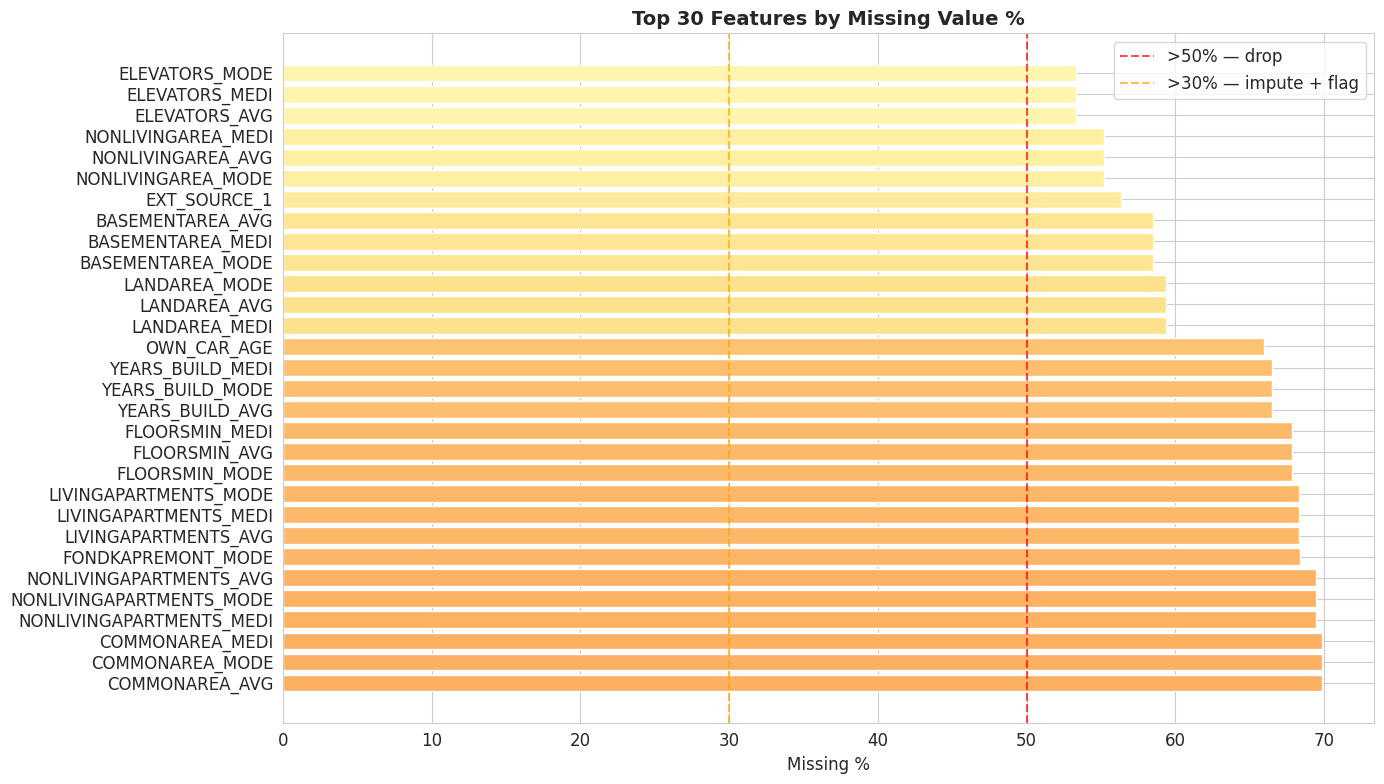

In [28]:
top_missing = missing_cols.head(30)

plt.figure(figsize=(14, 8))
plt.barh(top_missing.index,
         top_missing['Missing %'],
         color=plt.cm.RdYlGn_r(top_missing['Missing %'] / 100))
plt.xlabel('Missing %')
plt.title('Top 30 Features by Missing Value %', fontsize=14, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='>50% — drop')
plt.axvline(x=30, color='orange', linestyle='--', alpha=0.7, label='>30% — impute + flag')
plt.legend()
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Key Numerical Features

Focused on features most likely to carry default signal: income, loan amount, age, employment duration.

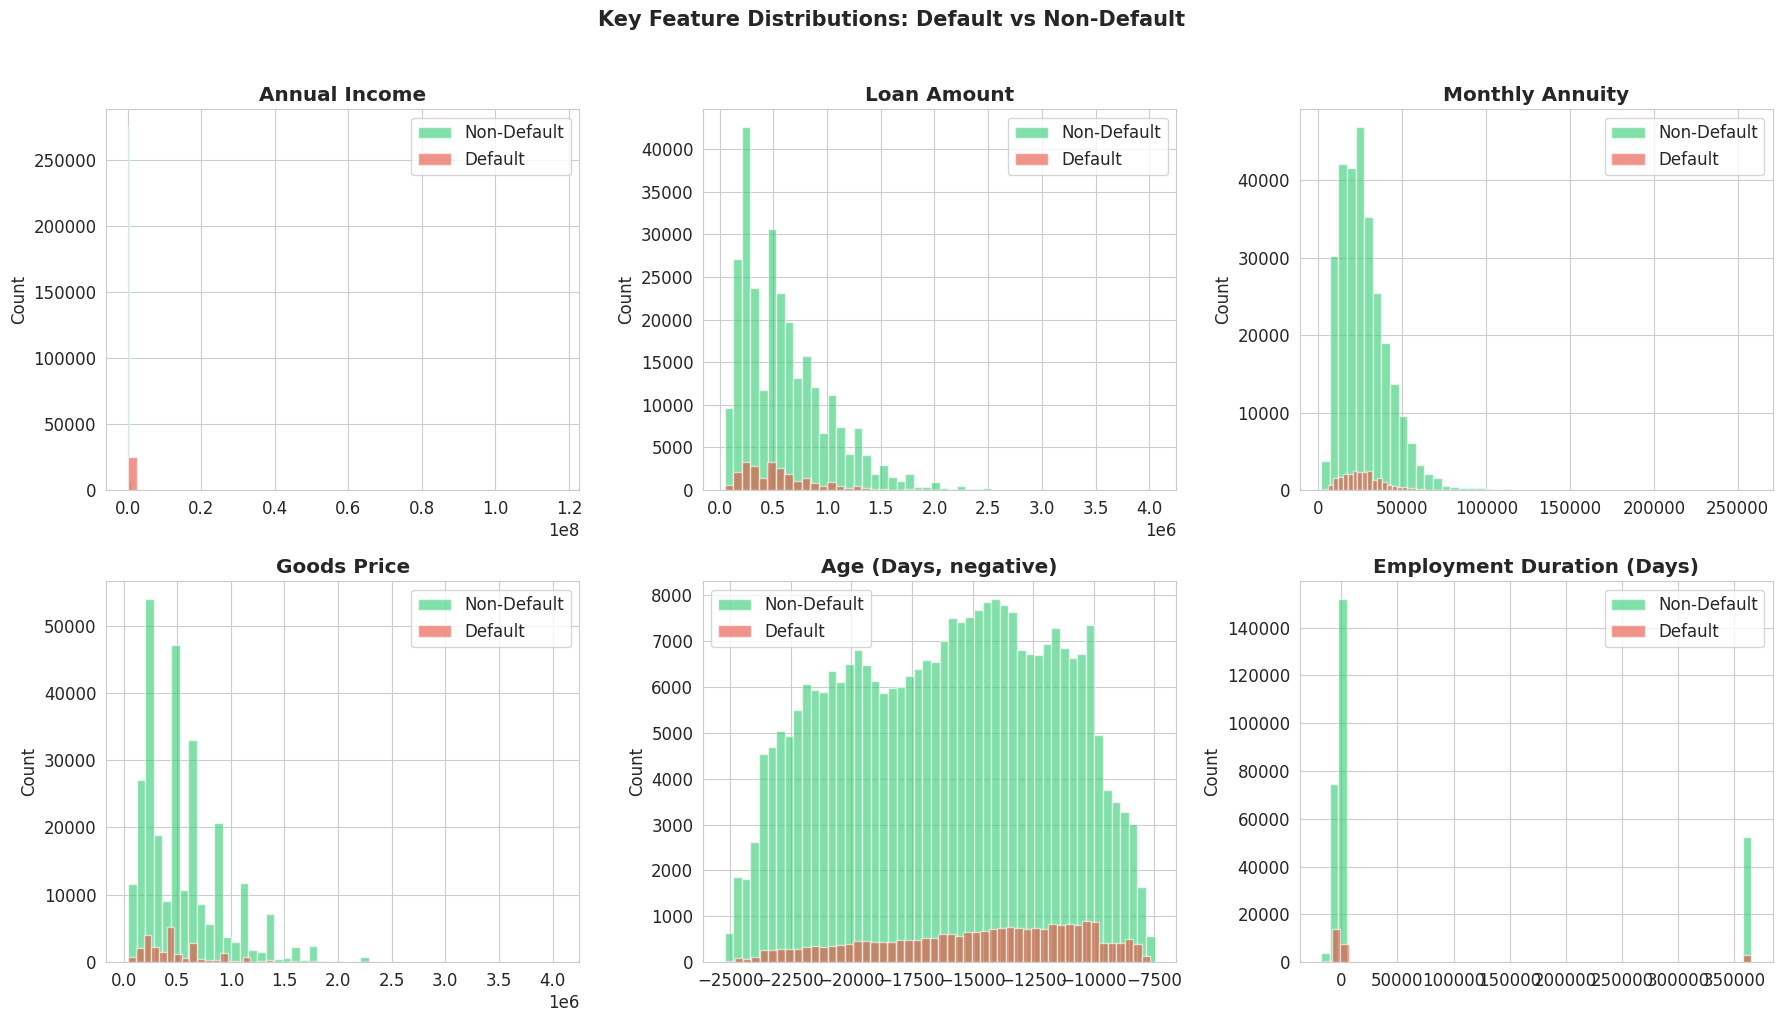

In [29]:
key_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

feature_labels = {
    'AMT_INCOME_TOTAL': 'Annual Income',
    'AMT_CREDIT': 'Loan Amount',
    'AMT_ANNUITY': 'Monthly Annuity',
    'AMT_GOODS_PRICE': 'Goods Price',
    'DAYS_BIRTH': 'Age (Days, negative)',
    'DAYS_EMPLOYED': 'Employment Duration (Days)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    df[df['TARGET'] == 0][feature].hist(bins=50, alpha=0.6,
                                        color='#2ecc71',
                                        label='Non-Default',
                                        ax=axes[i])
    df[df['TARGET'] == 1][feature].hist(bins=50, alpha=0.6,
                                        color='#e74c3c',
                                        label='Default',
                                        ax=axes[i])
    axes[i].set_title(feature_labels[feature], fontweight='bold')
    axes[i].legend()
    axes[i].set_ylabel('Count')

plt.suptitle('Key Feature Distributions: Default vs Non-Default',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
comparison = df.groupby('TARGET')[key_features].mean().T
comparison.columns = ['Non-Default', 'Default']
comparison['Diff %'] = ((comparison['Default'] - comparison['Non-Default'])
                        / comparison['Non-Default'] * 100).round(1)
print(comparison.to_string())

                    Non-Default        Default  Diff %
AMT_INCOME_TOTAL  169077.722266  165611.760906    -2.0
AMT_CREDIT        602648.282002  557778.527674    -7.4
AMT_ANNUITY        27163.623349   26481.744290    -2.5
AMT_GOODS_PRICE   542736.795003  488972.412554    -9.9
DAYS_BIRTH        -16138.176397  -14884.828077    -7.8
DAYS_EMPLOYED      65696.146123   42394.675448   -35.5


## 6 — Age & Employment

Younger borrowers and those with shorter employment history tend to default more. Verifying this in the data before building features around it.

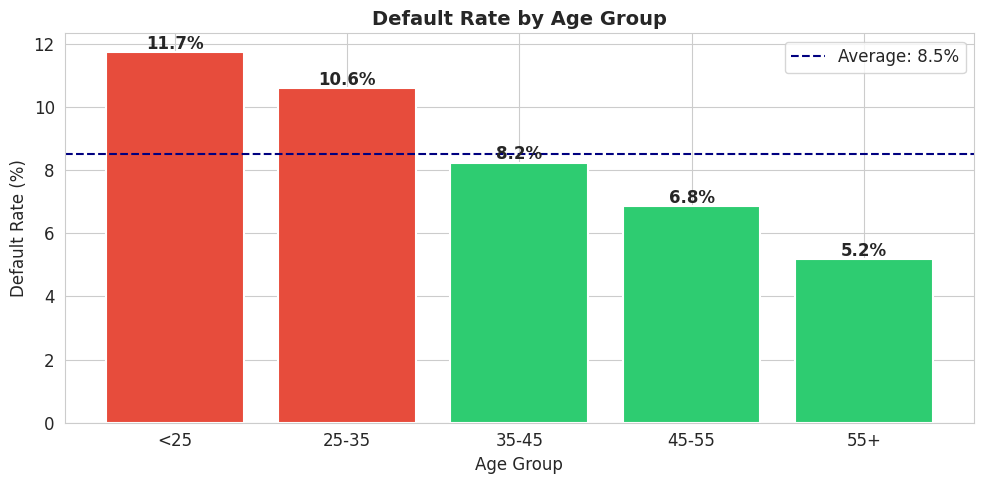

In [31]:
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)
df['AGE_BUCKET'] = pd.cut(df['AGE_YEARS'],
                           bins=[0, 25, 35, 45, 55, 100],
                           labels=['<25', '25-35', '35-45', '45-55', '55+'])

age_default = df.groupby('AGE_BUCKET')['TARGET'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(age_default.index, age_default.values,
               color=['#e74c3c' if x > age_default.mean() else '#2ecc71'
                      for x in age_default.values],
               edgecolor='white', linewidth=1.5)
plt.axhline(y=age_default.mean(), color='navy',
            linestyle='--', label=f'Average: {age_default.mean():.1f}%')
plt.title('Default Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')
plt.legend()
for bar, val in zip(bars, age_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('default_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Income vs Loan Amount

Borrowers taking loans they cannot afford relative to their income are the highest risk segment. This ratio becomes a core engineered feature in Notebook 2.

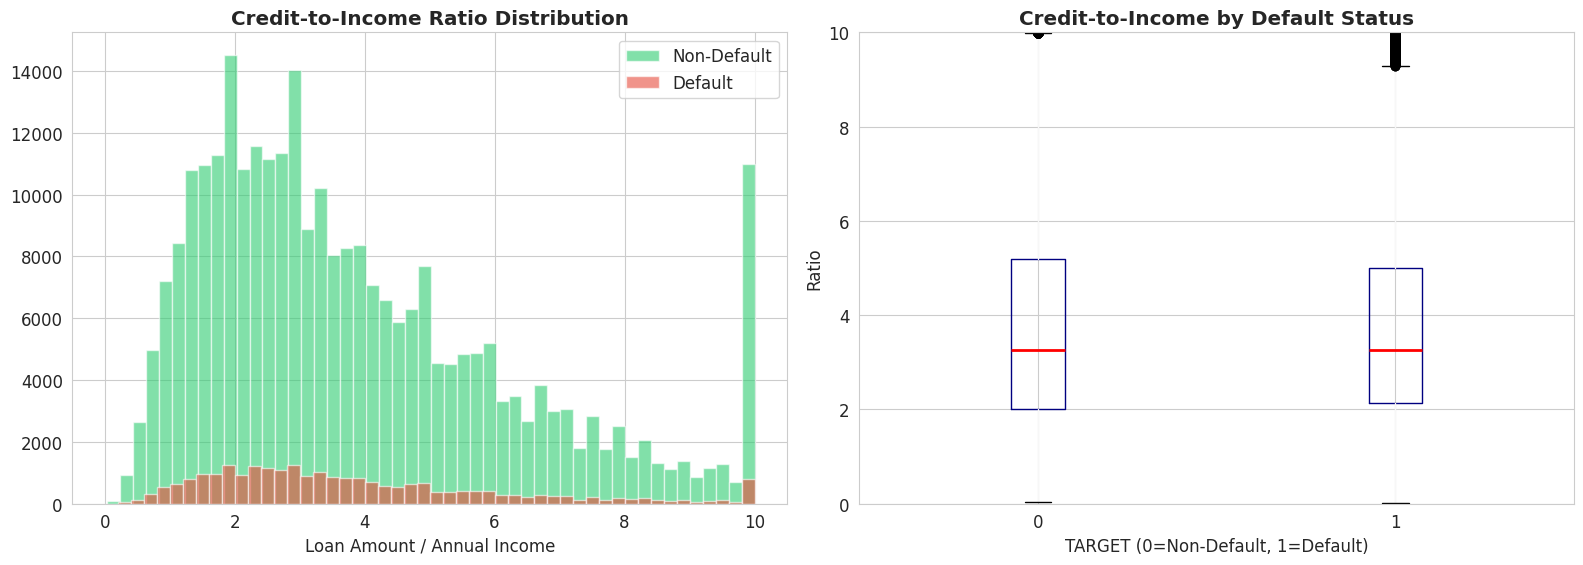

TARGET              0             1
count   282686.000000  24825.000000
mean         3.963729      3.887438
std          2.695055      2.627348
min          0.037500      0.004808
25%          2.000333      2.130435
50%          3.266653      3.253143
75%          5.191333      4.991667
max         49.227200     84.736842


In [32]:
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df[df['TARGET']==0]['CREDIT_INCOME_RATIO'].clip(0, 10).hist(
    bins=50, alpha=0.6, color='#2ecc71', label='Non-Default', ax=axes[0])
df[df['TARGET']==1]['CREDIT_INCOME_RATIO'].clip(0, 10).hist(
    bins=50, alpha=0.6, color='#e74c3c', label='Default', ax=axes[0])
axes[0].set_title('Credit-to-Income Ratio Distribution', fontweight='bold')
axes[0].set_xlabel('Loan Amount / Annual Income')
axes[0].legend()

df.boxplot(column='CREDIT_INCOME_RATIO', by='TARGET',
           ax=axes[1],
           boxprops=dict(color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Credit-to-Income by Default Status', fontweight='bold')
axes[1].set_xlabel('TARGET (0=Non-Default, 1=Default)')
axes[1].set_ylabel('Ratio')
axes[1].set_ylim(0, 10)
plt.suptitle('')

plt.tight_layout()
plt.savefig('credit_income_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('TARGET')['CREDIT_INCOME_RATIO'].describe().T.to_string())

## 8 — Correlation Analysis

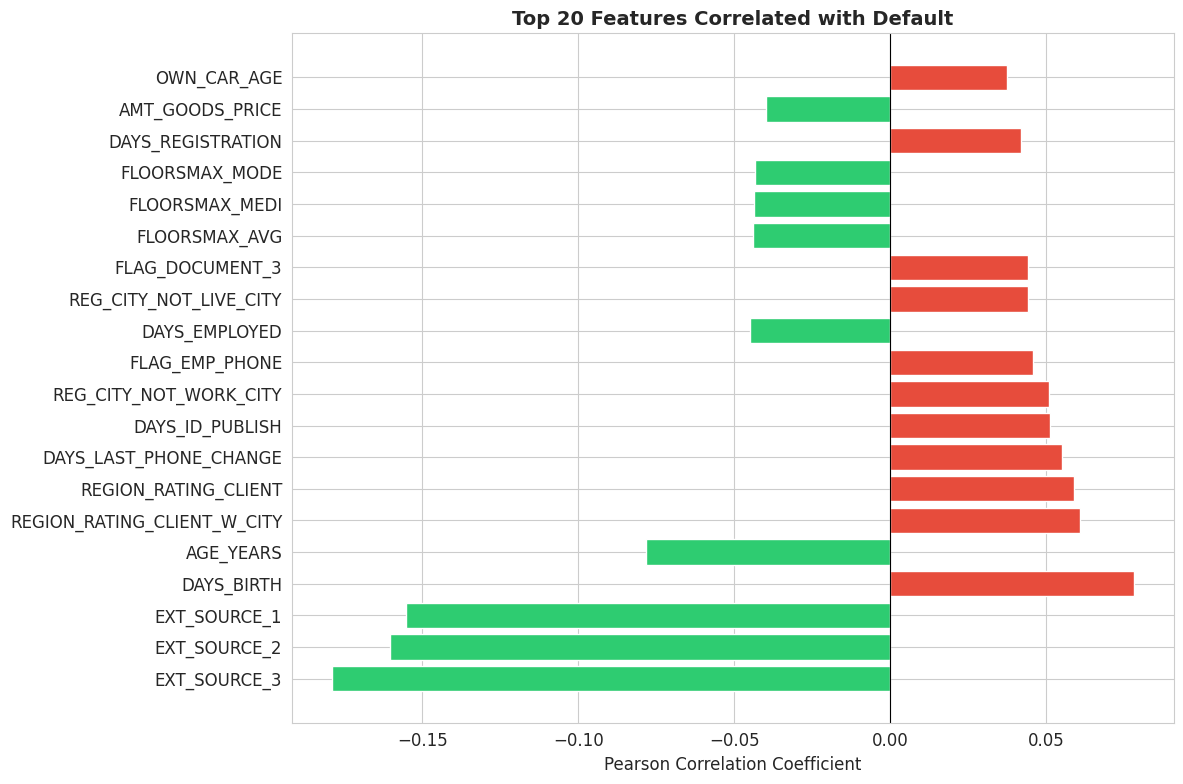

Red  = positive correlation with default
Green = negative correlation with default

EXT_SOURCE_3   -0.178919
EXT_SOURCE_2   -0.160472
EXT_SOURCE_1   -0.155317
DAYS_BIRTH      0.078239
AGE_YEARS      -0.078234


In [33]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numerical_cols].corr()['TARGET'].drop('TARGET')
correlations = correlations.sort_values(key=abs, ascending=False)

top_corr = correlations.head(20)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 20 Features Correlated with Default',
          fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('Red  = positive correlation with default')
print('Green = negative correlation with default')
print()
print(top_corr.head().to_string())

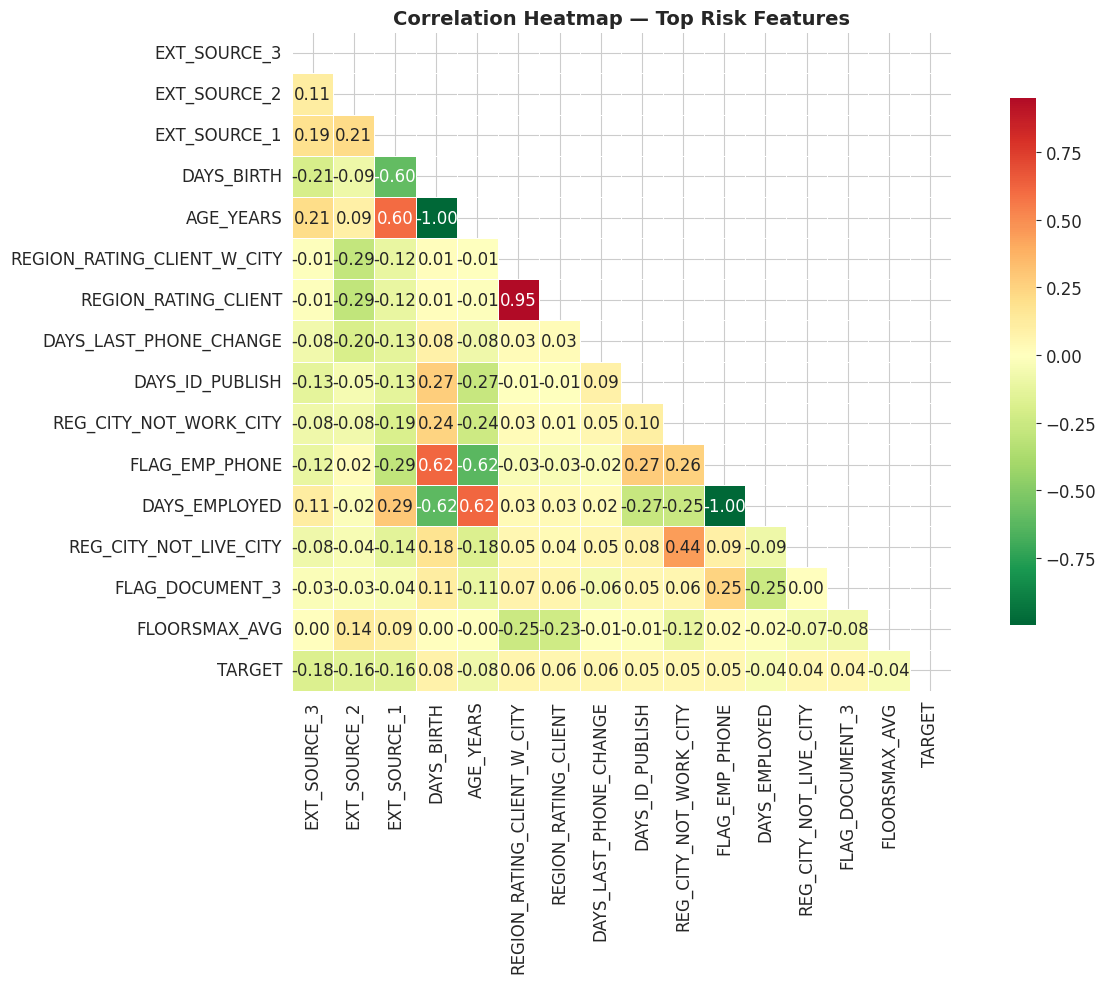

In [34]:
top_features = correlations.head(15).index.tolist() + ['TARGET']
corr_matrix = df[top_features].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Top Risk Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 — Categorical Features

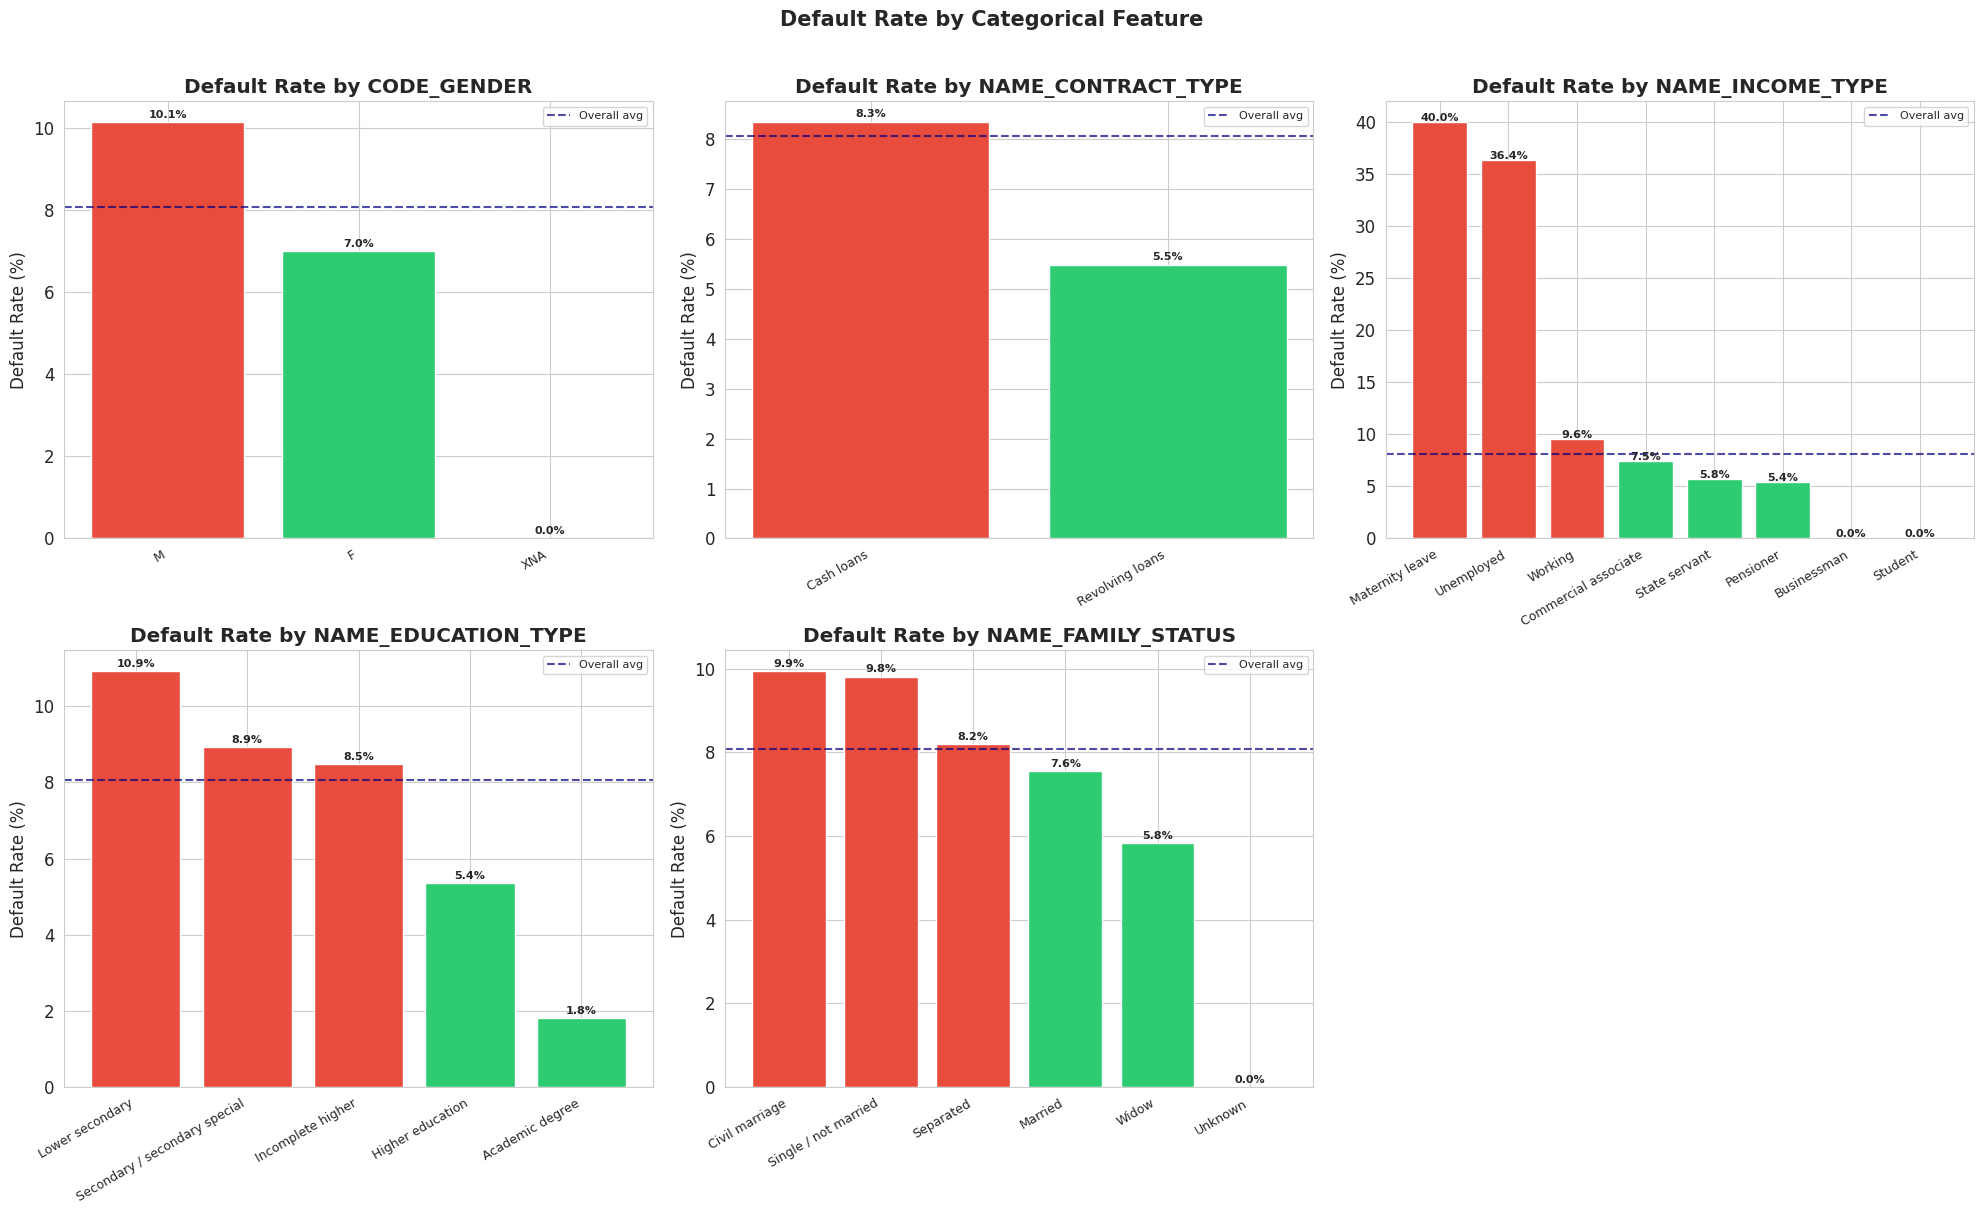

In [35]:
cat_features = [
    'CODE_GENDER',
    'NAME_CONTRACT_TYPE',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS'
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    default_rate = df.groupby(feature)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False)

    colors = ['#e74c3c' if x > df['TARGET'].mean()*100 else '#2ecc71'
              for x in default_rate.values]

    bars = axes[i].bar(range(len(default_rate)), default_rate.values,
                       color=colors, edgecolor='white')
    axes[i].set_xticks(range(len(default_rate)))
    axes[i].set_xticklabels(default_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].axhline(y=df['TARGET'].mean()*100, color='navy',
                    linestyle='--', alpha=0.7, label='Overall avg')
    axes[i].set_title(f'Default Rate by {feature}', fontweight='bold')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].legend(fontsize=8)

    for bar, val in zip(bars, default_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.1,
                     f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Default Rate by Categorical Feature',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 — Findings Summary

In [36]:
default_rate = df['TARGET'].mean() * 100
missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
high_missing = (df.isnull().mean() > 0.5).sum()

print(f"""
DATASET
  Rows                  : {df.shape[0]:,}
  Features              : {df.shape[1]}
  Overall missing       : {missing_pct:.1f}%
  Features >50% missing : {high_missing}

CLASS IMBALANCE
  Default rate          : {default_rate:.1f}%
  Ratio                 : {(100-default_rate)/default_rate:.0f}:1
  Approach              : SMOTE in Notebook 2

KEY RISK SIGNALS
  1. Credit-to-income ratio
  2. Age — younger borrowers default more
  3. Employment duration — shorter tenure, higher risk
  4. Annuity-to-income ratio
  5. External credit scores

FEATURE ENGINEERING (Notebook 2)
  - Drop features with >50% missing
  - Build ratio features: credit/income, annuity/income
  - Convert DAYS_BIRTH and DAYS_EMPLOYED to interpretable units
  - Flag missingness as binary indicator where meaningful

METRIC CHOICE
  - Accuracy is not appropriate given class imbalance
  - Primary  : Recall on default class
  - Secondary: ROC-AUC, F1, Precision-Recall curve
""")


DATASET
  Rows                  : 307,511
  Features              : 125
  Overall missing       : 23.8%
  Features >50% missing : 41

CLASS IMBALANCE
  Default rate          : 8.1%
  Ratio                 : 11:1
  Approach              : SMOTE in Notebook 2

KEY RISK SIGNALS
  1. Credit-to-income ratio
  2. Age — younger borrowers default more
  3. Employment duration — shorter tenure, higher risk
  4. Annuity-to-income ratio
  5. External credit scores

FEATURE ENGINEERING (Notebook 2)
  - Drop features with >50% missing
  - Build ratio features: credit/income, annuity/income
  - Convert DAYS_BIRTH and DAYS_EMPLOYED to interpretable units
  - Flag missingness as binary indicator where meaningful

METRIC CHOICE
  - Accuracy is not appropriate given class imbalance
  - Primary  : Recall on default class
  - Secondary: ROC-AUC, F1, Precision-Recall curve

